In [3]:
%%capture
%pip install scikit-survival

In [4]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sksurv.nonparametric import kaplan_meier_estimator
from sksurv.nonparametric import nelson_aalen_estimator
import time
import os
# import google

In [5]:
# Lung cancer drivers
GENE_PANEL = {
    7157: "TP53", 3845: "KRAS", 1956: "EGFR", 6794: "STK11",
    9817: "KEAP1", 5290: "PIK3CA", 1029: "CDKN2A", 2195: "FAT1",
    6657: "SOX2", 2260: "FGFR1", 673: "BRAF", 4233: "MET",
    5728: "PTEN", 4790: "NFE2L2", 4763: "NF1", 5925: "RB1",
    2064: "ERBB2", 238: "ALK", 6098: "ROS1", 5979: "RET"
}

BASE_URL = "https://www.cbioportal.org/api"
STUDY_IDS = ["luad_tcga_pan_can_atlas_2018", "lusc_tcga_pan_can_atlas_2018"]

In [6]:
# # clinical data
# def fetch_clin(data_type):
#     url = BASE_URL + "/studies/" + STUDY_ID + "/clinical-data?clinicalDataType=" + data_type
#     r = requests.get(url)
#     if r.status_code != 200:
#         return []
#     return r.json()

# pt_raw = fetch_clin("PATIENT")
# time.sleep(1)
# sm_raw = fetch_clin("SAMPLE")

# df_clin = pd.DataFrame(pt_raw + sm_raw)

# # filter and pivot
# target_cols = ["OS_MONTHS", "OS_STATUS", "AGE", "MUTATION_COUNT", "AJCC_PATHOLOGIC_TUMOR_STAGE"]

# clin_filtered = df_clin[df_clin["clinicalAttributeId"].isin(target_cols)]
# # Prevent duplication error if patients have multiple samples
# clin_filtered = clin_filtered.drop_duplicates(subset=["patientId", "clinicalAttributeId"], keep="first")

# clin_wide = clin_filtered.pivot(
#     index="patientId", columns="clinicalAttributeId", values="value"
# )

# # types and cleaning
# clin_wide["OS_MONTHS"] = pd.to_numeric(clin_wide["OS_MONTHS"], errors="coerce")
# clin_wide["AGE"] = pd.to_numeric(clin_wide["AGE"], errors="coerce")
# clin_wide["MUTATION_COUNT"] = pd.to_numeric(clin_wide["MUTATION_COUNT"], errors="coerce")
# clin_wide["OS_STATUS"] = clin_wide["OS_STATUS"].str.contains("DECEASED", case=False, na=False).astype(int)

# # molecular data
# payload = {
#     "entrezGeneIds": list(GENE_PANEL.keys()),
#     "sampleListId": STUDY_ID + "_all"
# }

# # mutations
# mut_url = BASE_URL + "/molecular-profiles/" + STUDY_ID + "_mutations/mutations/fetch"
# r_mut = requests.post(mut_url, json=payload)
# df_mut = pd.DataFrame(r_mut.json())

# df_mut["Gene"] = df_mut["entrezGeneId"].map(GENE_PANEL) + "_Mut"
# mut_matrix = df_mut.pivot_table(index="sampleId", columns="Gene", values="entrezGeneId", aggfunc="count", fill_value=0)
# mut_matrix.index = mut_matrix.index.str[:12]

# # rna
# rna_url = BASE_URL + "/molecular-profiles/" + STUDY_ID + "_rna_seq_v2_mrna/molecular-data/fetch"
# r_rna = requests.post(rna_url, json=payload)
# df_rna = pd.DataFrame(r_rna.json())

# df_rna["Gene"] = df_rna["entrezGeneId"].map(GENE_PANEL) + "_Exp"
# rna_matrix = df_rna.pivot_table(index="sampleId", columns="Gene", values="value")
# rna_matrix.index = rna_matrix.index.str[:12]

# # merge
# final_df = clin_wide.join(rna_matrix, how="inner").join(mut_matrix, how="left")

# # fill nans for mutation columns and drop missing values
# mut_cols = [g + "_Mut" for g in GENE_PANEL.values()]
# for col in mut_cols:
#     if col in final_df.columns:
#         final_df[col] = final_df[col].fillna(0).astype(int)

# final_df = final_df.dropna(subset=["OS_MONTHS", "AGE", "MUTATION_COUNT"])

# print(final_df.head())

In [7]:
def fetch_clin(data_type, study_id):
    url = f"{BASE_URL}/studies/{study_id}/clinical-data?clinicalDataType={data_type}"
    r = requests.get(url)
    if r.status_code != 200:
        return []
    return r.json()

# 3. FETCH AND COMBINE CLINICAL DATA
clin_data = []
for study in STUDY_IDS:
    clin_data.extend(fetch_clin("PATIENT", study))
    time.sleep(1)
    clin_data.extend(fetch_clin("SAMPLE", study))
    time.sleep(1)

df_clin = pd.DataFrame(clin_data)

target_cols = ["OS_MONTHS", "OS_STATUS", "AGE", "MUTATION_COUNT", "AJCC_PATHOLOGIC_TUMOR_STAGE"]
clin_filtered = df_clin[df_clin["clinicalAttributeId"].isin(target_cols)]
clin_filtered = clin_filtered.drop_duplicates(subset=["patientId", "clinicalAttributeId"], keep="first")

clin_wide = clin_filtered.pivot(
    index="patientId", columns="clinicalAttributeId", values="value"
)

# types and cleaning
clin_wide["OS_MONTHS"] = pd.to_numeric(clin_wide["OS_MONTHS"], errors="coerce")
clin_wide["AGE"] = pd.to_numeric(clin_wide["AGE"], errors="coerce")
clin_wide["MUTATION_COUNT"] = pd.to_numeric(clin_wide["MUTATION_COUNT"], errors="coerce")
clin_wide["OS_STATUS"] = clin_wide["OS_STATUS"].str.contains("DECEASED", case=False, na=False).astype(int)

# 4. MAP STAGES TO NUMBERS (DeepSurv needs numeric inputs!)
stage_map = {
    'STAGE I': 1, 'STAGE IA': 1, 'STAGE IB': 1,
    'STAGE II': 2, 'STAGE IIA': 2, 'STAGE IIB': 2,
    'STAGE III': 3, 'STAGE IIIA': 3, 'STAGE IIIB': 3,
    'STAGE IV': 4
}
# Only apply to rows that have a string stage
clin_wide['STAGE_NUM'] = clin_wide['AJCC_PATHOLOGIC_TUMOR_STAGE'].str.upper().map(stage_map)

# 5. FETCH AND COMBINE MOLECULAR DATA
df_mut_list = []
df_rna_list = []

for study in STUDY_IDS:
    payload = {"entrezGeneIds": list(GENE_PANEL.keys()), "sampleListId": f"{study}_all"}

    # Mutations
    url_mut = f"{BASE_URL}/molecular-profiles/{study}_mutations/mutations/fetch"
    r_mut = requests.post(url_mut, json=payload)
    df_mut_list.extend(r_mut.json())

    # RNA
    url_rna = f"{BASE_URL}/molecular-profiles/{study}_rna_seq_v2_mrna/molecular-data/fetch"
    r_rna = requests.post(url_rna, json=payload)
    df_rna_list.extend(r_rna.json())

# Pivot Mutations
df_mut = pd.DataFrame(df_mut_list)
df_mut["Gene"] = df_mut["entrezGeneId"].map(GENE_PANEL) + "_Mut"
mut_matrix = df_mut.pivot_table(index="sampleId", columns="Gene", values="entrezGeneId", aggfunc="count", fill_value=0)
mut_matrix.index = mut_matrix.index.str[:12]

# Pivot RNA
df_rna = pd.DataFrame(df_rna_list)
df_rna["Gene"] = df_rna["entrezGeneId"].map(GENE_PANEL) + "_Exp"
rna_matrix = df_rna.pivot_table(index="sampleId", columns="Gene", values="value")
rna_matrix.index = rna_matrix.index.str[:12]

# 6. FINAL MERGE AND CLEANUP
final_df = clin_wide.join(rna_matrix, how="inner").join(mut_matrix, how="left")

# Fill missing mutations with 0
mut_cols = [g + "_Mut" for g in GENE_PANEL.values()]
for col in mut_cols:
    if col in final_df.columns:
        final_df[col] = final_df[col].fillna(0).astype(int)

# Drop rows missing crucial survival or numeric stage data, and drop the old text stage column
final_df = final_df.dropna(subset=["OS_MONTHS", "AGE", "MUTATION_COUNT", "STAGE_NUM"])
final_df = final_df.drop('AJCC_PATHOLOGIC_TUMOR_STAGE', axis=1)

print(f"Total Pan-Lung (NSCLC) Patients Ready for ML: {final_df.shape[0]}")
print(final_df.head())

Total Pan-Lung (NSCLC) Patients Ready for ML: 935
               AGE  MUTATION_COUNT  OS_MONTHS  OS_STATUS  STAGE_NUM  ALK_Exp  \
TCGA-05-4244  70.0           192.0   0.000000          0        4.0   6.6323   
TCGA-05-4249  67.0           300.0  50.070684          0        1.0   7.0830   
TCGA-05-4250  79.0           312.0   3.978039          1        3.0   1.6580   
TCGA-05-4382  68.0          1547.0  19.955946          0        1.0   9.3329   
TCGA-05-4384  66.0           117.0  14.005326          0        3.0   5.4979   

              BRAF_Exp  CDKN2A_Exp  EGFR_Exp  ERBB2_Exp  ...  NF1_Mut  \
TCGA-05-4244   195.829     39.4450  2347.770   10643.50  ...        0   
TCGA-05-4249   132.002    235.0280  1615.540    8495.47  ...        0   
TCGA-05-4250   207.909    538.8380   792.154    7639.89  ...        0   
TCGA-05-4382   143.343    471.9080   626.496    9857.66  ...        0   
TCGA-05-4384   117.899     85.5223   582.156   12105.70  ...        0   

              NFE2L2_Mut  PIK3

In [8]:
display(final_df)

,AGE,MUTATION_COUNT,OS_MONTHS,OS_STATUS,STAGE_NUM,ALK_Exp,BRAF_Exp,CDKN2A_Exp,EGFR_Exp,ERBB2_Exp,...,NF1_Mut,NFE2L2_Mut,PIK3CA_Mut,PTEN_Mut,RB1_Mut,RET_Mut,ROS1_Mut,SOX2_Mut,STK11_Mut,TP53_Mut
TCGA-05-4244,70.0,192.0,0.000000,0,4.0,6.6323,195.829,39.4450,2347.770,10643.50,...,0,0,0,0,0,0,0,0,0,0
TCGA-05-4249,67.0,300.0,50.070684,0,1.0,7.0830,132.002,235.0280,1615.540,8495.47,...,0,0,1,0,0,0,0,0,0,0
TCGA-05-4250,79.0,312.0,3.978039,1,3.0,1.6580,207.909,538.8380,792.154,7639.89,...,0,0,0,0,0,0,0,0,0,0
TCGA-05-4382,68.0,1547.0,19.955946,0,1.0,9.3329,143.343,471.9080,626.496,9857.66,...,0,0,0,0,0,0,1,0,0,1
TCGA-05-4384,66.0,117.0,14.005326,0,3.0,5.4979,117.899,85.5223,582.156,12105.70,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-O2-A52V,75.0,220.0,43.889930,1,2.0,6.3032,288.686,1920.7900,3911.670,3183.11,...,0,0,0,1,0,0,0,0,0,1
TCGA-O2-A52W,63.0,110.0,8.580728,1,1.0,12.8963,274.584,832.8850,2028.760,2112.31,...,0,0,0,0,0,0,0,0,0,1
TCGA-O2-A5IB,71.0,227.0,11.177960,1,3.0,3.1949,185.836,1840.7900,722.574,5928.11,...,1,1,0,0,1,0,0,0,0,0
TCGA-S2-AA1A,68.0,102.0,16.865569,0,1.0,3.2760,148.729,316.4590,459.266,3247.80,...,0,0,0,0,0,0,0,0,0,0


In [9]:
import seaborn as sns

# visual style
sns.set_theme(style="whitegrid")

# feature engineering
# count mutations per patient for specific target genes
mut_cols = [c for c in final_df.columns if "_Mut" in c]
final_df["PANEL_MUT_BURDEN"] = final_df[mut_cols].sum(axis=1)

# check for nulls
null_counts = final_df.isnull().sum()
print(null_counts[null_counts > 0])

if null_counts.sum() == 0:
    print("Zero null values remaining.")

# set columns for analysis
numeric_cols = ["AGE", "MUTATION_COUNT", "OS_MONTHS"] + [c for c in final_df.columns if "_Exp" in c]
cat_cols = ["OS_STATUS", "PANEL_MUT_BURDEN"]

# summary stats
# focusing on mean, median, min, and max
stats = final_df[numeric_cols].describe().T[["mean", "50%", "min", "max"]]
print(stats)

Series([], dtype: int64)
Zero null values remaining.
                       mean          50%       min          max
AGE               66.172193    67.000000   38.0000      90.0000
MUTATION_COUNT   278.288770   213.000000    1.0000    1590.0000
OS_MONTHS         29.963156    21.040865    0.0000     238.2878
ALK_Exp           18.654356     5.007400    0.0000     883.9510
BRAF_Exp         211.100409   186.076000   42.2374     935.9290
CDKN2A_Exp       656.610608   266.708000    0.9266    7634.2700
EGFR_Exp        2575.549274  1438.180000   12.5168   80121.9000
ERBB2_Exp       6000.715117  4014.960000  320.3090  278328.0000
FAT1_Exp        4105.239440  3259.390000   86.6347   47344.6000
FGFR1_Exp       1630.683618   994.882000   49.0868   69408.6000
KEAP1_Exp       2096.873563  1725.850000  128.8890   19003.1000
KRAS_Exp        1715.289168  1397.870000  483.7320   29832.8000
MET_Exp         4746.299413  2816.900000   19.3833  104610.0000
NF1_Exp         1934.405437  1844.610000  127.2520 

In [10]:
# Calculate the raw counts
censored_count = (final_df['OS_STATUS'] == 0).sum()
deceased_count = (final_df['OS_STATUS'] == 1).sum()
total_patients = len(final_df)

# Calculate the percentages
percent_censored = (censored_count / total_patients) * 100
percent_deceased = (deceased_count / total_patients) * 100

print(f"Total Patients: {total_patients}")
print(f"Censored (Living/Lost): {censored_count} ({percent_censored:.1f}%)")
print(f"Uncensored (Deceased):  {deceased_count} ({percent_deceased:.1f}%)")

Total Patients: 935
Censored (Living/Lost): 565 (60.4%)
Uncensored (Deceased):  370 (39.6%)


In [11]:
# map stage strings to numbers
stage_map = {
    'STAGE I': 1, 'STAGE IA': 1, 'STAGE IB': 1,
    'STAGE II': 2, 'STAGE IIA': 2, 'STAGE IIB': 2,
    'STAGE III': 3, 'STAGE IIIA': 3, 'STAGE IIIB': 3, 'STAGE IIIC': 3,
    'STAGE IV': 4
}

# convert stage column to numeric values
# final_df['STAGE_NUM'] = final_df['AJCC_PATHOLOGIC_TUMOR_STAGE'].str.upper().map(stage_map)

# drop rows with unknown or missing stage
final_df = final_df.dropna(subset=['STAGE_NUM'])

# remove original text column
# final_df = final_df.drop('AJCC_PATHOLOGIC_TUMOR_STAGE', axis=1)

print("Unique stages:")
print(final_df['STAGE_NUM'].unique())
print("New shape:")
print(final_df.shape)

Unique stages:
[4. 1. 3. 2.]
New shape:
(935, 46)


In [12]:
display(final_df)

,AGE,MUTATION_COUNT,OS_MONTHS,OS_STATUS,STAGE_NUM,ALK_Exp,BRAF_Exp,CDKN2A_Exp,EGFR_Exp,ERBB2_Exp,...,NFE2L2_Mut,PIK3CA_Mut,PTEN_Mut,RB1_Mut,RET_Mut,ROS1_Mut,SOX2_Mut,STK11_Mut,TP53_Mut,PANEL_MUT_BURDEN
TCGA-05-4244,70.0,192.0,0.000000,0,4.0,6.6323,195.829,39.4450,2347.770,10643.50,...,0,0,0,0,0,0,0,0,0,1
TCGA-05-4249,67.0,300.0,50.070684,0,1.0,7.0830,132.002,235.0280,1615.540,8495.47,...,0,1,0,0,0,0,0,0,0,3
TCGA-05-4250,79.0,312.0,3.978039,1,3.0,1.6580,207.909,538.8380,792.154,7639.89,...,0,0,0,0,0,0,0,0,0,1
TCGA-05-4382,68.0,1547.0,19.955946,0,1.0,9.3329,143.343,471.9080,626.496,9857.66,...,0,0,0,0,0,1,0,0,1,7
TCGA-05-4384,66.0,117.0,14.005326,0,3.0,5.4979,117.899,85.5223,582.156,12105.70,...,0,0,0,0,0,0,0,0,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-O2-A52V,75.0,220.0,43.889930,1,2.0,6.3032,288.686,1920.7900,3911.670,3183.11,...,0,0,1,0,0,0,0,0,1,3
TCGA-O2-A52W,63.0,110.0,8.580728,1,1.0,12.8963,274.584,832.8850,2028.760,2112.31,...,0,0,0,0,0,0,0,0,1,1
TCGA-O2-A5IB,71.0,227.0,11.177960,1,3.0,3.1949,185.836,1840.7900,722.574,5928.11,...,1,0,0,1,0,0,0,0,0,3
TCGA-S2-AA1A,68.0,102.0,16.865569,0,1.0,3.2760,148.729,316.4590,459.266,3247.80,...,0,0,0,0,0,0,0,0,0,0


In [13]:
# save data
final_df.to_csv("./data/tcga_processed_lung.csv", index=False)

In [14]:
# # # upload tcga data to Google drive to use in other notebooks
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

# final_df.to_csv('/content/drive/MyDrive/tcga_ready_for_ml.csv', index=False)

# print("Data successfully saved to Google Drive!")

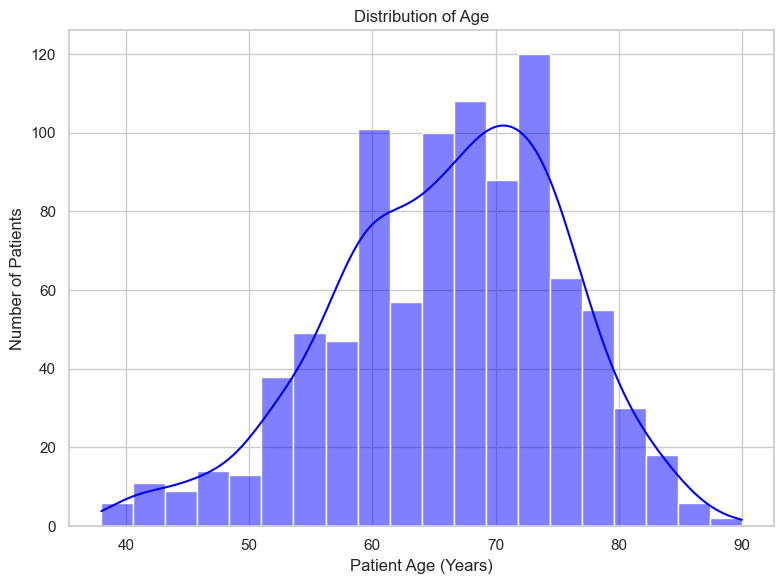

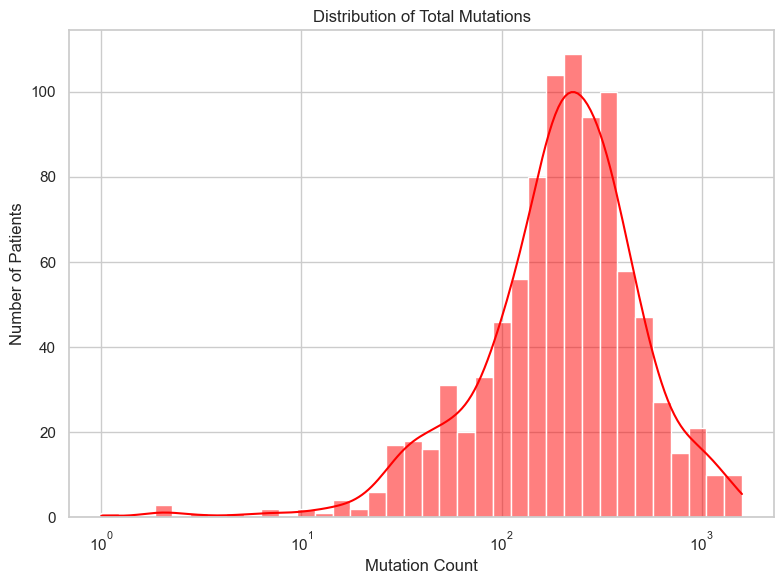

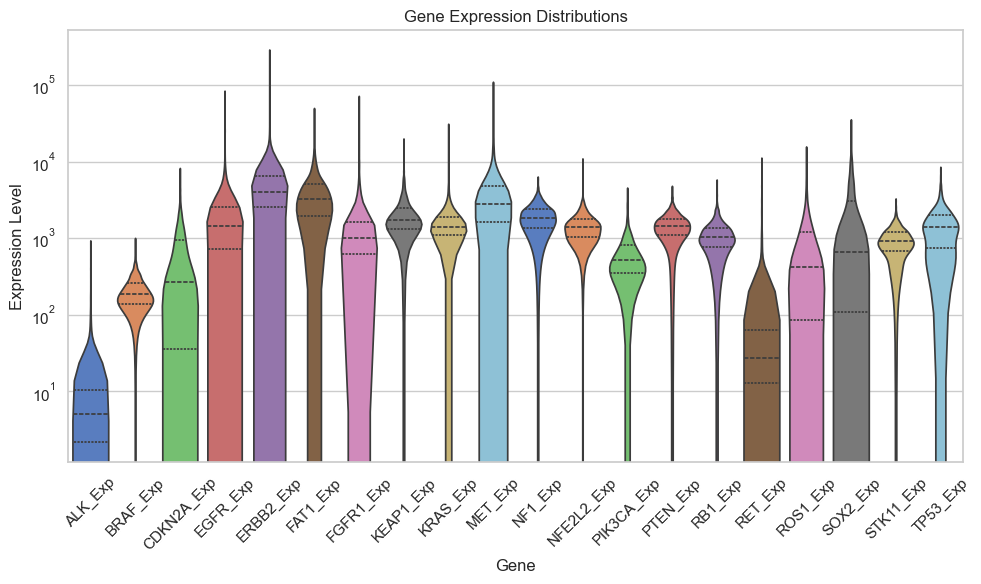

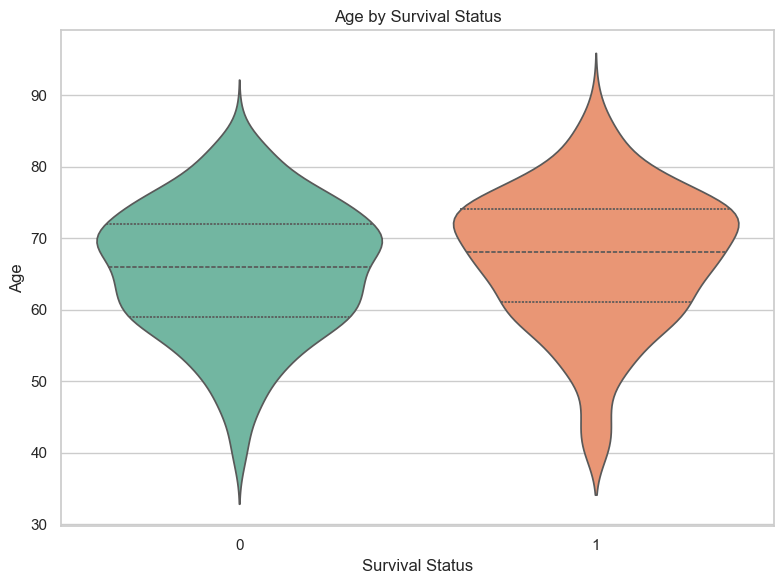

In [15]:
# plot age distribution
plt.figure(figsize=(8, 6))
sns.histplot(data=final_df, x='AGE', kde=True, color='blue')
plt.title('Distribution of Age')
plt.xlabel('Patient Age (Years)')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

# plot mutation count distribution with log scale
plt.figure(figsize=(8, 6))
sns.histplot(data=final_df, x='MUTATION_COUNT', kde=True, log_scale=True, color='red')
plt.title('Distribution of Total Mutations')
plt.xlabel('Mutation Count')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

# plot gene expression distributions
plt.figure(figsize=(10, 6))
exp_cols = [c for c in final_df.columns if '_Exp' in c]
df_exp_melt = final_df[exp_cols].melt(var_name='Gene', value_name='Expression')

sns.violinplot(
    data=df_exp_melt,
    x='Gene',
    y='Expression',
    hue='Gene',
    palette='muted',
    inner='quartile',
    legend=False
)
plt.yscale('log')
plt.title('Gene Expression Distributions')
plt.xlabel('Gene')
plt.ylabel('Expression Level')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# compare age distribution against survival status
plt.figure(figsize=(8, 6))
sns.violinplot(
    data=final_df,
    x='OS_STATUS',
    y='AGE',
    hue='OS_STATUS',
    palette='Set2',
    inner='quartile',
    legend=False
)
plt.title('Age by Survival Status')
plt.xlabel('Survival Status')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

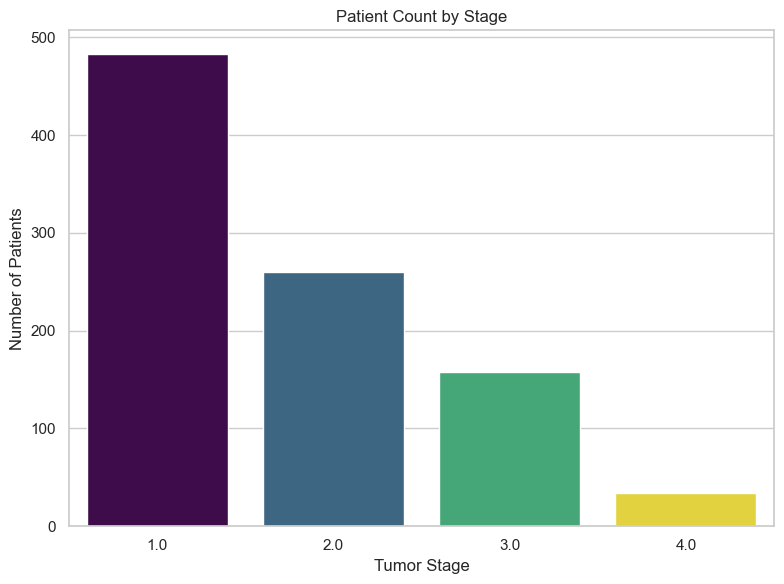

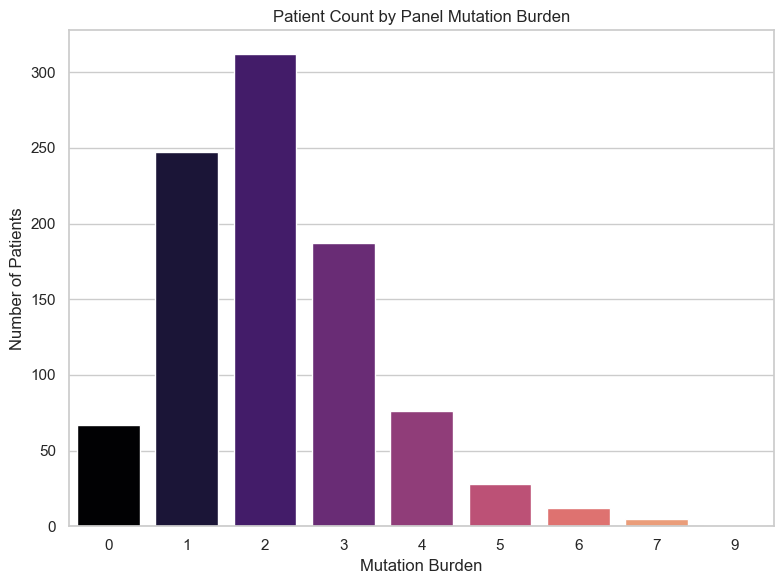

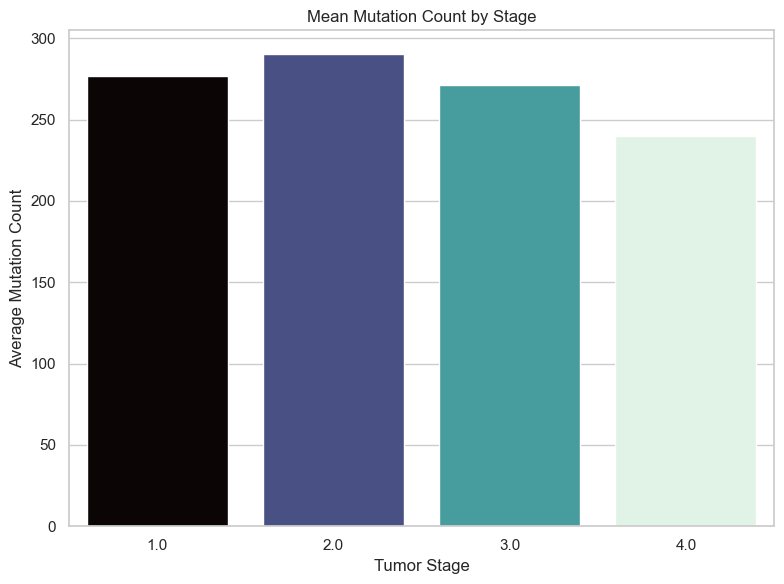

In [16]:
# plot patient counts per stage
plt.figure(figsize=(8, 6))
sns.countplot(
    data=final_df,
    x='STAGE_NUM',
    hue='STAGE_NUM',
    palette='viridis',
    legend=False
)
plt.title('Patient Count by Stage')
plt.xlabel('Tumor Stage')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

# plot mutation burden counts
plt.figure(figsize=(8, 6))
sns.countplot(
    data=final_df,
    x='PANEL_MUT_BURDEN',
    hue='PANEL_MUT_BURDEN',
    palette='magma',
    legend=False
)
plt.title('Patient Count by Panel Mutation Burden')
plt.xlabel('Mutation Burden')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

# calculate and plot average mutation count by stage
plt.figure(figsize=(8, 6))
stage_means = final_df.groupby('STAGE_NUM')['MUTATION_COUNT'].mean().reset_index()

sns.barplot(
    data=stage_means,
    x='STAGE_NUM',
    y='MUTATION_COUNT',
    hue='STAGE_NUM',
    palette='mako',
    legend=False
)
plt.title('Mean Mutation Count by Stage')
plt.xlabel('Tumor Stage')
plt.ylabel('Average Mutation Count')
plt.tight_layout()
plt.show()

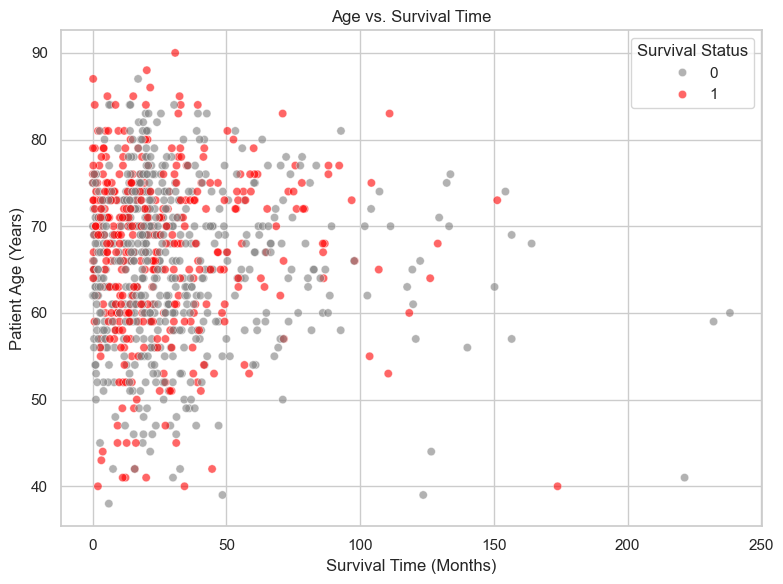

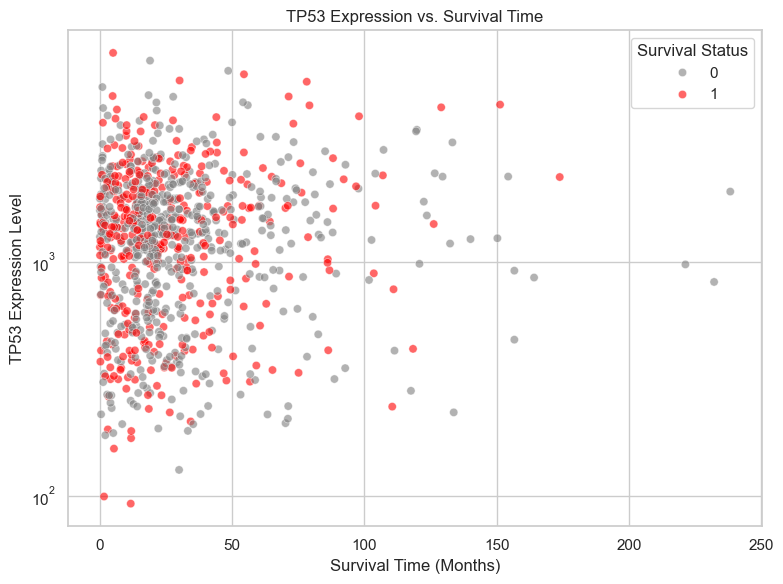

In [17]:
# scatter plot for age vs survival time
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=final_df,
    x='OS_MONTHS',
    y='AGE',
    hue='OS_STATUS',
    alpha=0.6,
    palette={0: 'gray', 1: 'red'}
)
plt.title('Age vs. Survival Time')
plt.xlabel('Survival Time (Months)')
plt.ylabel('Patient Age (Years)')
plt.legend(title='Survival Status')
plt.tight_layout()
plt.show()

# scatter plot for tp53 expression vs survival time
if 'TP53_Exp' in final_df.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=final_df,
        x='OS_MONTHS',
        y='TP53_Exp',
        hue='OS_STATUS',
        alpha=0.6,
        palette={0: 'gray', 1: 'red'}
    )
    plt.yscale('log')
    plt.title('TP53 Expression vs. Survival Time')
    plt.xlabel('Survival Time (Months)')
    plt.ylabel('TP53 Expression Level')
    plt.legend(title='Survival Status')
    plt.tight_layout()
    plt.show()

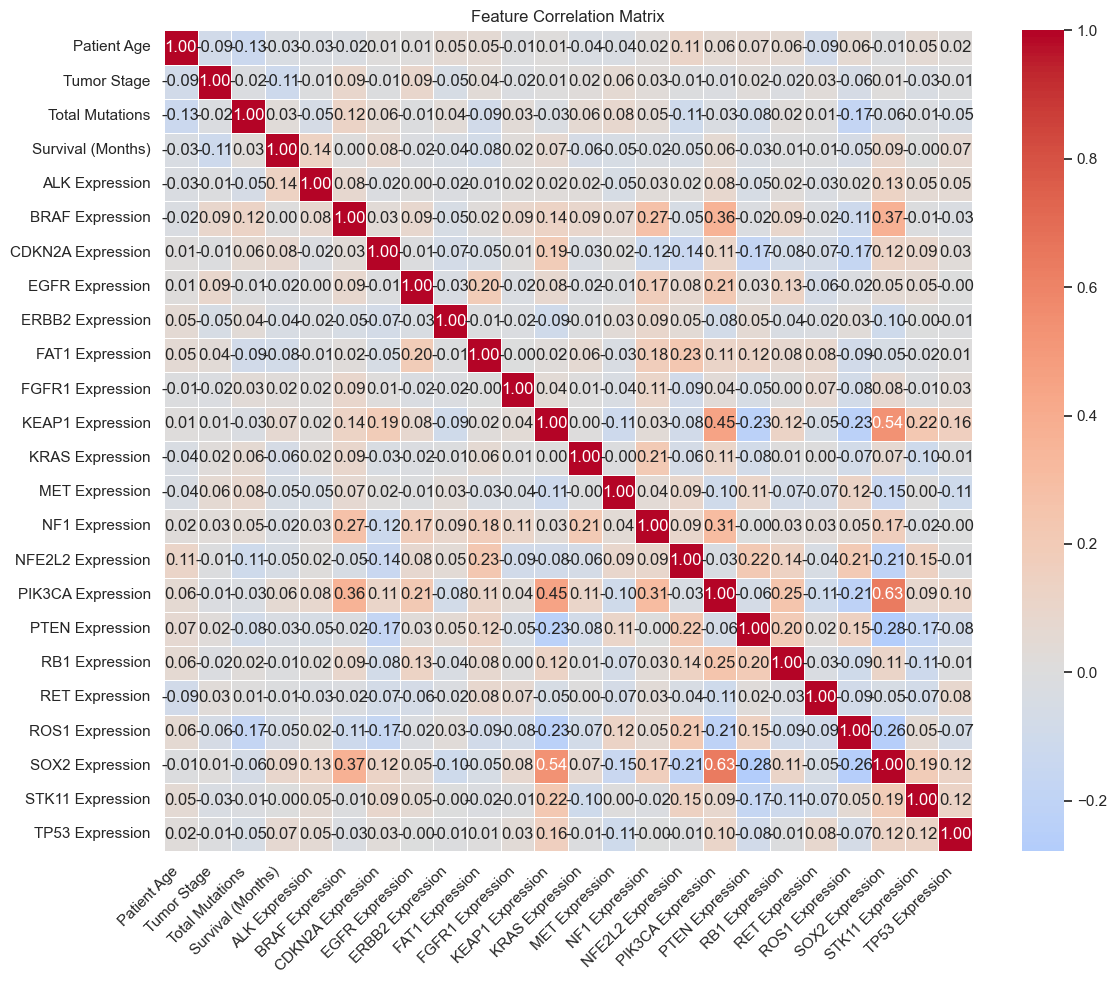

In [18]:
# select columns for correlation
cols_to_corr = ['AGE', 'STAGE_NUM', 'MUTATION_COUNT', 'OS_MONTHS'] + [c for c in final_df.columns if '_Exp' in c]

# calculate pearson correlation
corr_matrix = final_df[cols_to_corr].corr()

# create labels for axes
clean_labels = []
for col in cols_to_corr:
    if col == 'AGE':
        clean_labels.append('Patient Age')
    elif col == 'STAGE_NUM':
        clean_labels.append('Tumor Stage')
    elif col == 'MUTATION_COUNT':
        clean_labels.append('Total Mutations')
    elif col == 'OS_MONTHS':
        clean_labels.append('Survival (Months)')
    elif '_Exp' in col:
        clean_labels.append(col.replace('_Exp', ' Expression'))
    else:
        clean_labels.append(col)

# plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    xticklabels=clean_labels,
    yticklabels=clean_labels
)
plt.title('Feature Correlation Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

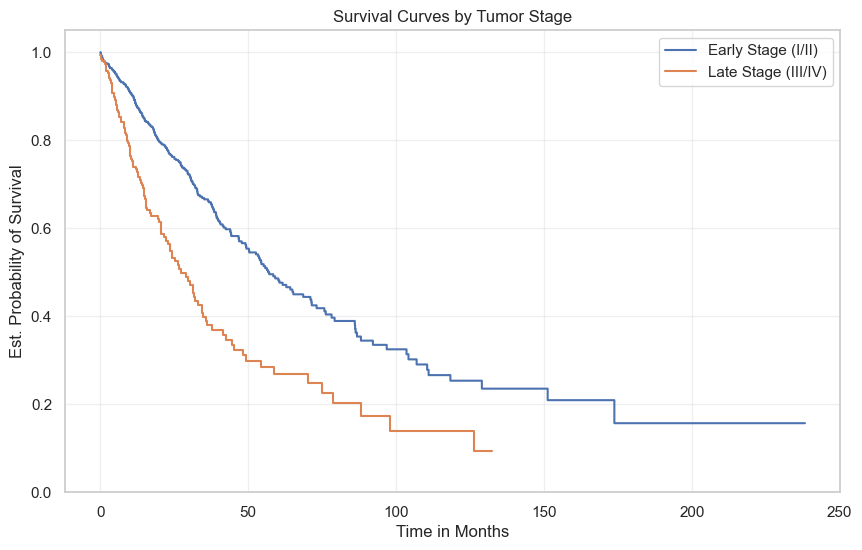

In [19]:
# group patients into early and late stages
early_stage = final_df[final_df['STAGE_NUM'] <= 2]
late_stage = final_df[final_df['STAGE_NUM'] > 2]

groups = [
    ("Early Stage (I/II)", early_stage),
    ("Late Stage (III/IV)", late_stage)
]

plt.figure(figsize=(10, 6))

for label, df_group in groups:
    # calculate km estimate
    time, survival_prob = kaplan_meier_estimator(
        df_group["OS_STATUS"].astype(bool),
        df_group["OS_MONTHS"]
    )
    plt.step(time, survival_prob, where="post", label=label)

plt.ylim(0, 1.05)
plt.ylabel("Est. Probability of Survival")
plt.xlabel("Time in Months")
plt.title("Survival Curves by Tumor Stage")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.show()

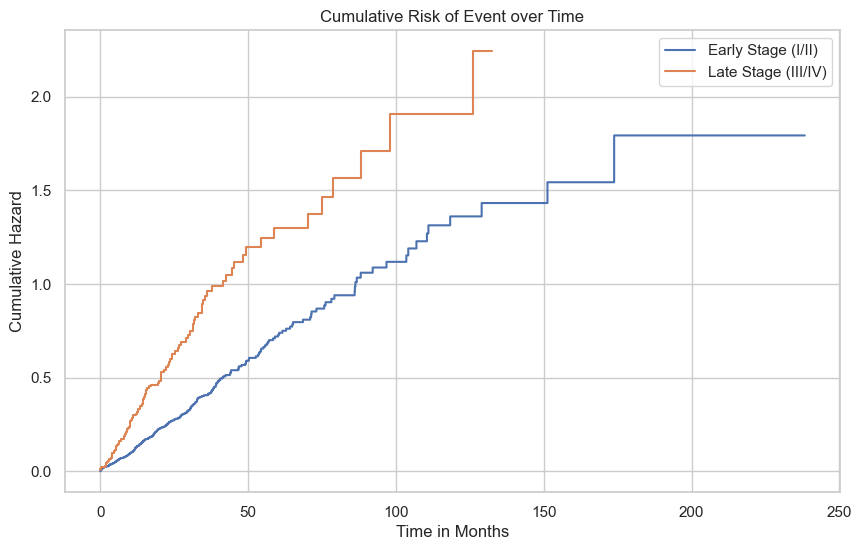

In [20]:
plt.figure(figsize=(10, 6))

for label, df_group in groups:
    time, cumulative_hazard = nelson_aalen_estimator(
        df_group["OS_STATUS"].astype(bool),
        df_group["OS_MONTHS"]
    )
    plt.step(time, cumulative_hazard, where="post", label=label)

plt.ylabel("Cumulative Hazard")
plt.xlabel("Time in Months")
plt.title("Cumulative Risk of Event over Time")
plt.legend(loc="best")
plt.show()